In [1]:
# banknotes.csv

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("banknotes.csv")
df

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [7]:
# check the null values or not
df.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [8]:
df.isnull().values.any()

np.False_

In [9]:
# check for pattern through viz

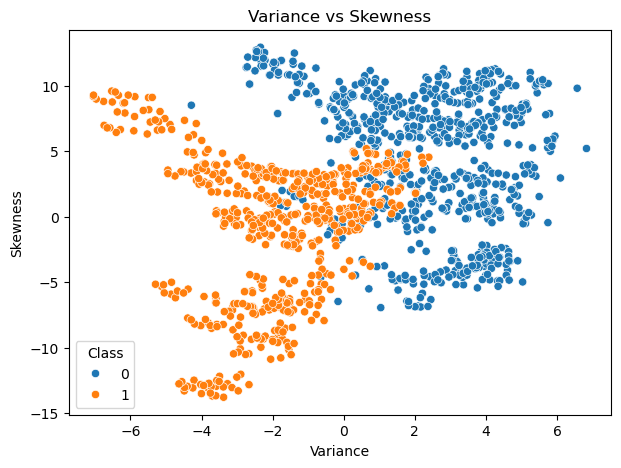

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Variance",
    y="Skewness",
    hue="Class",
    data=df
)
plt.title("Variance vs Skewness")
plt.show()

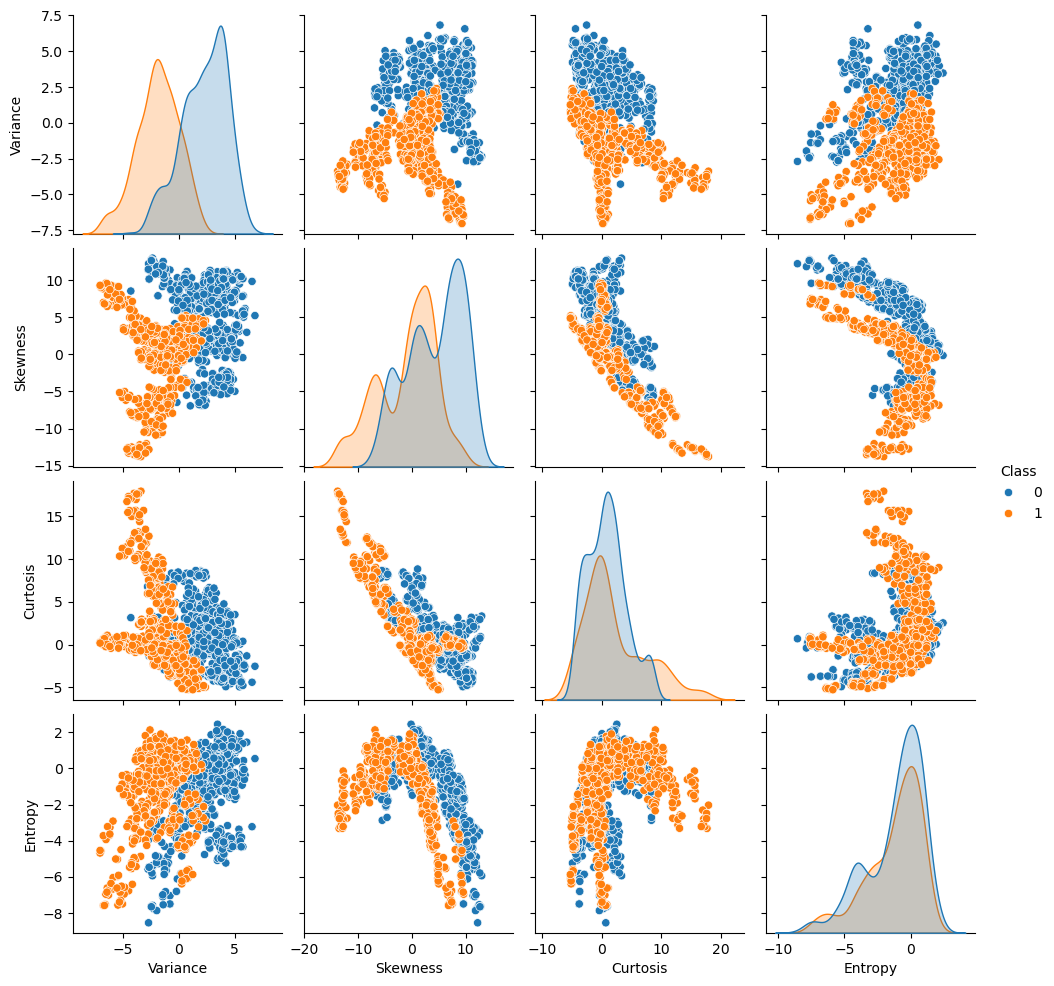

In [11]:
sns.pairplot(df,hue='Class');

In [12]:
# check the distribution of target variable (countplot)

In [13]:
x=df.drop('Class',axis=1)
y=df['Class']

<Axes: xlabel='Class', ylabel='count'>

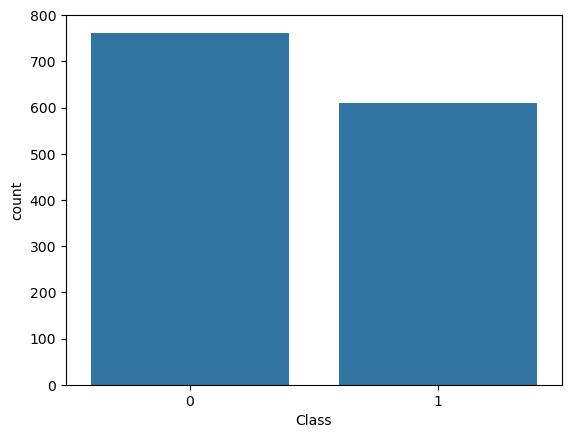

In [14]:
sns.countplot(x=y)

In [15]:
df['Class'].value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [16]:
# cross validation

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [19]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((1029, 4), (1029,), (343, 4), (343,))

In [20]:
# build a decision tree
# and also evaluate

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [22]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred = dt.predict(x_test)

In [25]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9883381924198251

In [26]:
x.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [27]:
dt.feature_importances_

array([0.59738345, 0.2197106 , 0.15354608, 0.02935987])

In [28]:
# plot the graph to viz feature importances 

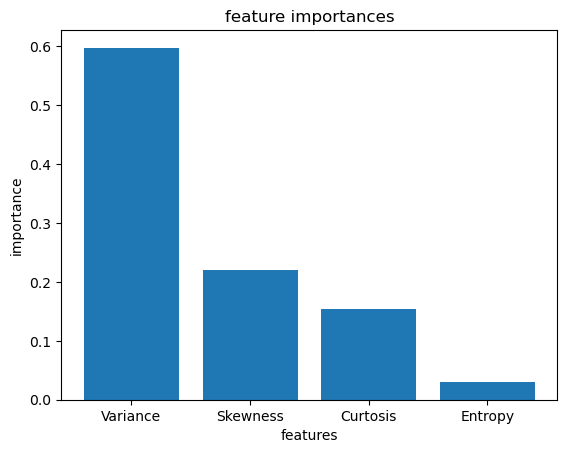

In [29]:
plt.title("feature importances")
plt.xlabel('features')
plt.ylabel("importance")
plt.bar(x.columns, dt.feature_importances_);

In [111]:
# plot the tree

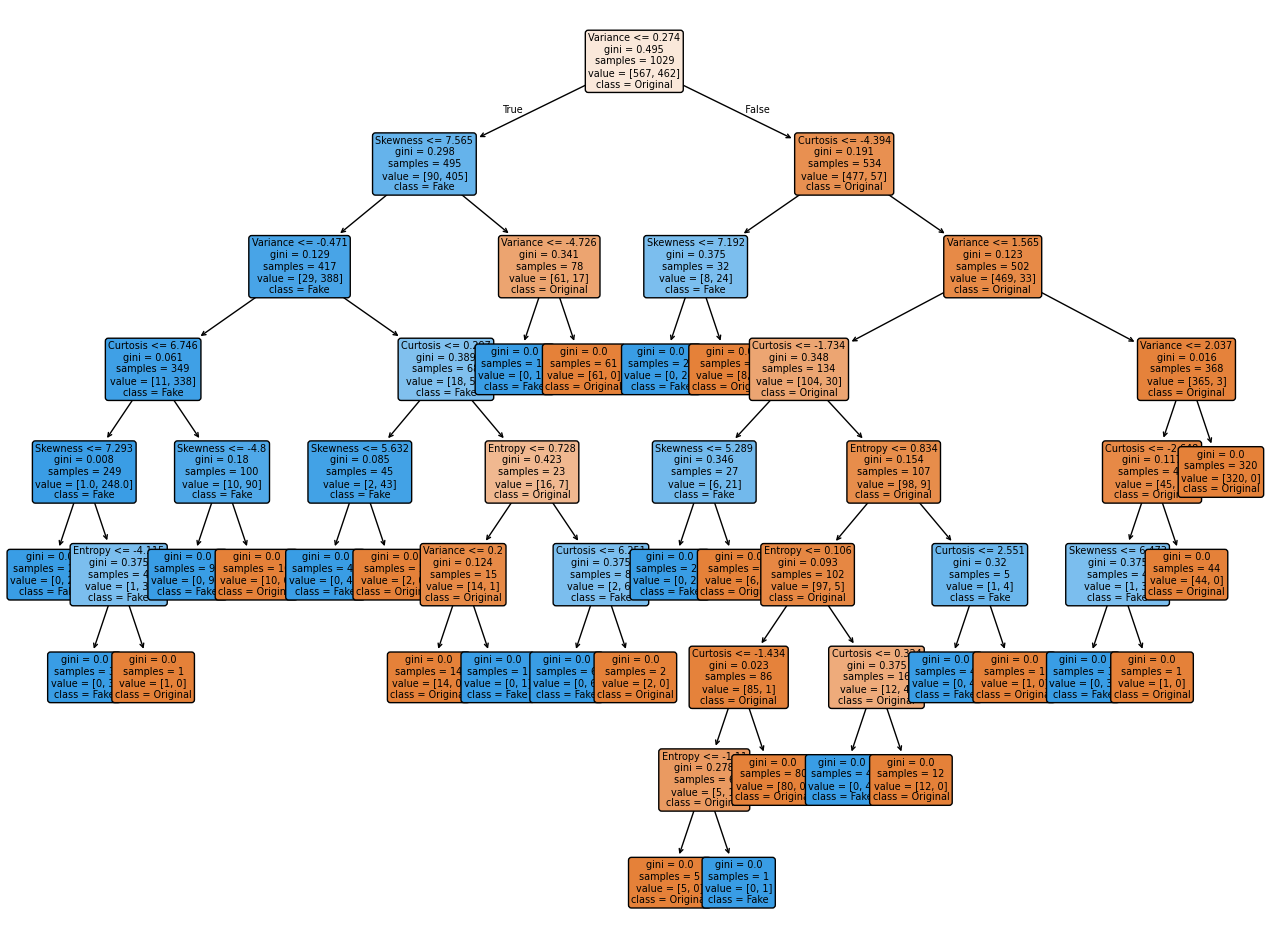

In [31]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 12))
plot_tree(dt, rounded= True, fontsize= 7, filled= True,
          class_names= ['Original', 'Fake'],
          feature_names= x.columns);

In [32]:
"""
4.86600
-1.63830
0.92442
0.645
"""

'\n4.86600\n-1.63830\n0.92442\n0.645\n'

In [35]:
new=[[4.86600,-1.63830,0.9242,0.645]]

In [36]:
dt.predict(new)

C:\Users\Sakshi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])